In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import glob, os
from sklearn.linear_model import LogisticRegression, SGDOneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
def report(model_name, y_test, fpr, tpr, thresholds):
    fpr_thresholds = [0.01, 0.05]
    for threshold in fpr_thresholds:
        fpr_max_index = np.where(fpr <= threshold)[0][-1]
        actual_recall, actual_fpr, actual_threshold = tpr[fpr_max_index], fpr[fpr_max_index], thresholds[fpr_max_index]

        print(f"{model_name} Results at {threshold*100}% FPR:")
        print(f"  Actual FPR: {actual_fpr * 100:.3f}%")
        print(f"  Recall: {actual_recall * 100:.3f}%")
        print(f"  Threshold: {actual_threshold * 100:.3f}%")
        print()

In [3]:
globbed = glob.glob(os.path.join('TrafficLabelling', '*.csv'))
# encoding = 'latin1' from Gemini, otherwise encountering error with decoding CSV data
dfs = [pd.read_csv(file, encoding='latin1', low_memory=False) for file in globbed]
data = pd.concat(dfs, ignore_index=True)

In [4]:
cleaned_columns = []
for col in data.columns:
    cleaned_columns.append(col.strip().lower().replace(' ', '_'))
data.columns = cleaned_columns

data['timestamp'] = pd.to_datetime(data['timestamp'], errors='coerce')
data['malicious'] = (data['label'] != 'BENIGN').astype(int)
data.drop(columns=['label'], inplace=True)
data.replace([np.inf, -np.inf], np.nan, inplace=True)

data.dropna(inplace=True)
data.sort_values('timestamp', inplace=True)

index = int(len(data) * 0.8)
train = data.iloc[:index].copy()
test = data.iloc[index:].copy()

to_remove = ['flow_id', 'source_ip', 'destination_ip', 'timestamp']
train.drop(to_remove, errors='ignore', inplace=True)
test.drop(to_remove, errors='ignore', inplace=True)

x_train = train.drop(columns=['malicious'])
y_train = train['malicious']

x_test = test.drop(columns=['malicious'])
y_test = test['malicious']

non_numeric_cols = x_train.select_dtypes(exclude=[np.number]).columns.tolist()
x_train.drop(columns=non_numeric_cols, inplace=True)
x_test.drop(columns=non_numeric_cols, inplace=True)

In [5]:
len(data.columns)

85

In [6]:
scaler = StandardScaler()
x_train_scaler = scaler.fit_transform(x_train)
x_test_scaler = scaler.transform(x_test)

logistic_regression = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
logistic_regression.fit(x_train_scaler, y_train)

prediction_lr = logistic_regression.predict(x_test_scaler)
probability_lr = logistic_regression.predict_proba(x_test_scaler)[:, 1]

fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, probability_lr)

In [7]:
report("LogisticRegression", y_test, fpr_lr, tpr_lr, thresholds_lr)
print("Standard Classification Report Results (50% FPR)")
print(classification_report(y_test, prediction_lr))

LogisticRegression Results at 1.0% FPR:
  Actual FPR: 1.000%
  Recall: 63.870%
  Threshold: 86.688%

LogisticRegression Results at 5.0% FPR:
  Actual FPR: 4.999%
  Recall: 78.070%
  Threshold: 66.876%

Standard Classification Report Results (50% FPR)
              precision    recall  f1-score   support

           0       0.95      0.92      0.93    311399
           1       0.84      0.90      0.87    148280

    accuracy                           0.91    459679
   macro avg       0.90      0.91      0.90    459679
weighted avg       0.91      0.91      0.91    459679



In [8]:
randomforest = RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42)
randomforest.fit(x_train, y_train)

prediction_rf = randomforest.predict(x_test)
probability_rf = randomforest.predict_proba(x_test)[:, 1]

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, probability_rf)

In [9]:
report("RandomForestClassifier", y_test, fpr_rf, tpr_rf, thresholds_rf)
print("Standard Classification Report Results (50% FPR)")
print(classification_report(y_test, prediction_rf))


RandomForestClassifier Results at 1.0% FPR:
  Actual FPR: 0.945%
  Recall: 67.307%
  Threshold: 16.000%

RandomForestClassifier Results at 5.0% FPR:
  Actual FPR: 4.998%
  Recall: 89.018%
  Threshold: 2.000%

Standard Classification Report Results (50% FPR)
              precision    recall  f1-score   support

           0       0.86      1.00      0.93    311399
           1       1.00      0.67      0.80    148280

    accuracy                           0.89    459679
   macro avg       0.93      0.83      0.86    459679
weighted avg       0.91      0.89      0.89    459679



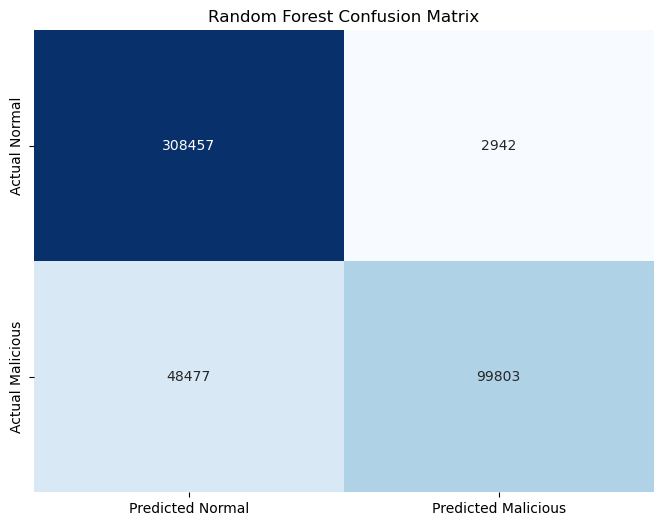

In [10]:
custom_predictions_rf = (probability_rf >= thresholds_rf[np.where(fpr_rf <= 0.01)[0][-1]]).astype(int)
cm = confusion_matrix(y_test, custom_predictions_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Normal', 'Predicted Malicious'],
            yticklabels=['Actual Normal', 'Actual Malicious'])
plt.title('Random Forest Confusion Matrix')
plt.show()

In [11]:
x_train_benign = x_train[y_train == 0]
isolationforest = IsolationForest(n_estimators=300, contamination='auto', n_jobs=-1, random_state=42)
isolationforest.fit(x_train_benign)

y_scores_if = -1 * isolationforest.decision_function(x_test)

fpr_if, tpr_if, thresholds_if = roc_curve(y_test, y_scores_if)

report("IsolationForest", y_test, fpr_if, tpr_if, thresholds_if)

IsolationForest Results at 1.0% FPR:
  Actual FPR: 0.999%
  Recall: 0.000%
  Threshold: 20.727%

IsolationForest Results at 5.0% FPR:
  Actual FPR: 4.999%
  Recall: 14.483%
  Threshold: 9.445%



In [12]:
x_train_benign_scaled = x_train_scaler[(y_train == 0).values]
svm = SGDOneClassSVM(nu=0.2, random_state=42)
svm.fit(x_train_benign_scaled)

y_scores_svm = -1 * svm.decision_function(x_test_scaler)

fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_scores_svm)

report("IsolationForest", y_test, fpr_svm, tpr_svm, thresholds_svm)

IsolationForest Results at 1.0% FPR:
  Actual FPR: 0.999%
  Recall: 54.656%
  Threshold: 69.354%

IsolationForest Results at 5.0% FPR:
  Actual FPR: 4.997%
  Recall: 74.251%
  Threshold: 13.225%



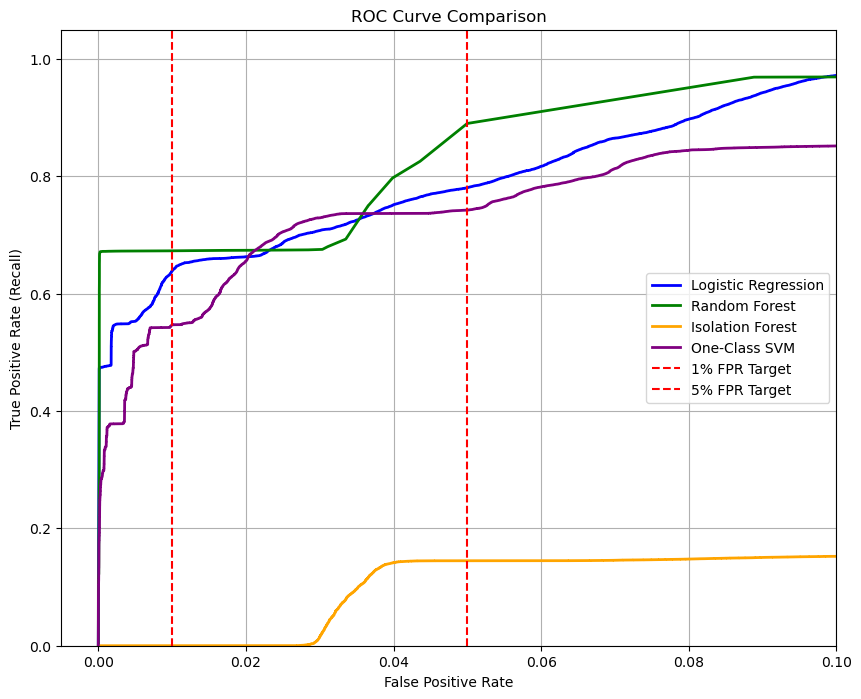

In [34]:
plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label='Logistic Regression')
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label='Random Forest')
plt.plot(fpr_if, tpr_if, color='orange', lw=2, label='Isolation Forest')
plt.plot(fpr_svm, tpr_svm, color='purple', lw=2, label='One-Class SVM')

plt.axvline(x=0.01, color='red', linestyle='--', label='1% FPR Target')
plt.axvline(x=0.05, color='red', linestyle='--', label='5% FPR Target')

plt.xlim([-0.005, 0.1])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid()
plt.show()

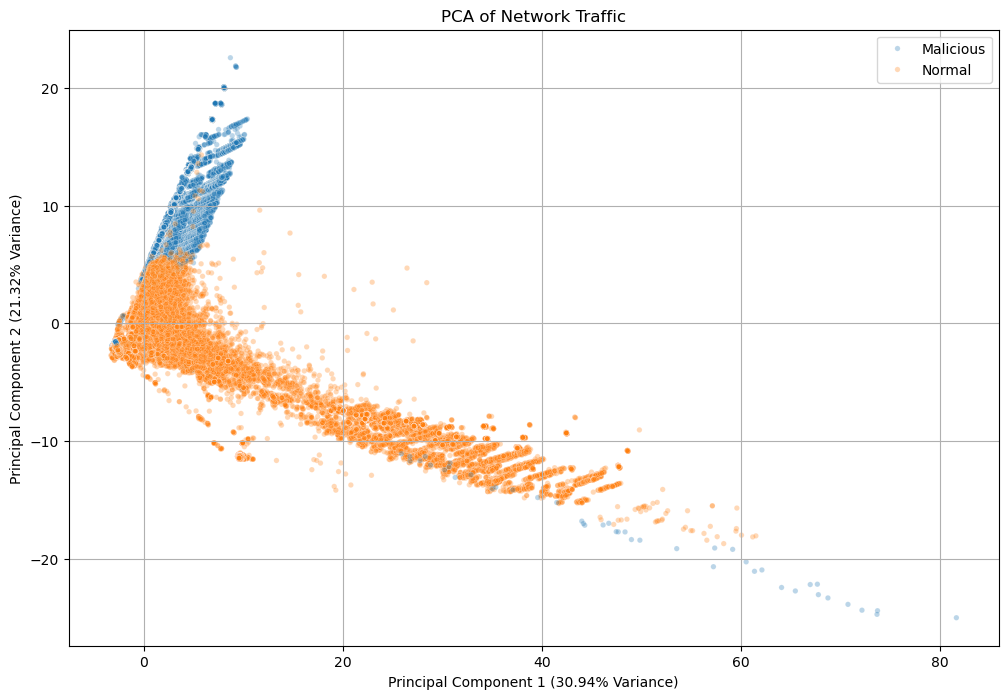

In [ ]:
pca = PCA(n_components=2, random_state=42)
pca_results = pca.fit_transform(x_test_scaler)

pca_df = pd.DataFrame({
    'Principal Component 1': pca_results[:, 0],
    'Principal Component 2': pca_results[:, 1],
    'Label': ['Malicious' if y == 1 else 'Normal' for y in y_test]
})

plt.figure(figsize=(12, 8))
sns.scatterplot(data=pca_df, x='Principal Component 1', y='Principal Component 2', hue='Label', alpha=0.3, s=15)

plt.title('PCA of Network Traffic')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}% Variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}% Variance)')
plt.legend()
plt.grid()
plt.show()

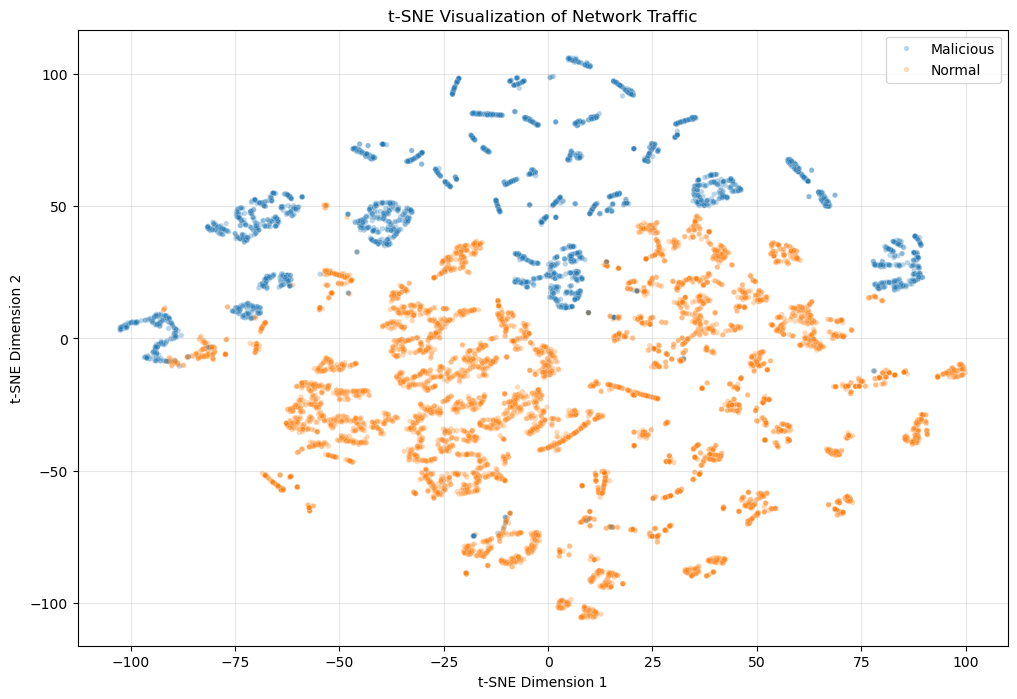

In [ ]:
random_samples = np.random.choice(len(x_test_scaler), 10000, replace=False)
x_sample_scaled = x_test_scaler[random_samples]
y_sample = y_test.iloc[random_samples].values

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_results = tsne.fit_transform(x_sample_scaled)

tsne_df = pd.DataFrame({
    't-SNE Dimension 1': tsne_results[:, 0],
    't-SNE Dimension 2': tsne_results[:, 1],
    'Label': ['Malicious' if y == 1 else 'Normal' for y in y_sample]
})

plt.figure(figsize=(12, 8))
sns.scatterplot(data=tsne_df, x='t-SNE Dimension 1', y='t-SNE Dimension 2', hue='Label', alpha=0.3, s=15)

plt.title('t-SNE Visualization of Network Traffic')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend()
plt.grid(alpha=0.3)
plt.show()